In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import importlib
#importlib.reload(plt)
import scipy.stats as stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import json

def eda(df):
    # overview of the dataset
    
    print("Dimensions of the dataset: ")
    print(df.shape)
    print(df.head())
    print("Here are all the columns present in the dataframe: ")
    for i in df.columns:
        print(i)

    # Missing value info
    
    print("Number of missing values in each column: ")
    x = df.columns
    y = df.isnull().sum()
    plt.xlabel("Columns")
    plt.ylabel("No of missing values")
    plt.title("Number of Missing values in the dataset")
    plt.xticks(rotation=45, ha='right')
    plt.bar(x,y)
    plt.show()

    # Remove columns with more than 50% missing values
    
    for i in x:
        if df[i].isna().sum() > len(df[i]) * 0.5:
            print("This feature:" + i + "has more than 50% missing values")
            df = df.drop(columns = [i])

    # Seperating numerical and categorical columns
    
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include=['object','string','category']).columns.tolist()

    # Outlier handling

    for z in num_cols:
        z_score_out = zscore(df[z])
        outliers_z = df[abs(z_score_out) > 3]
        Q1 = df[z].quantile(0.25)
        Q3 = df[z].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_iqr = df[
            (df[z] < lower) |
            (df[z] > upper)
        ]
        outliers = pd.concat([outliers_iqr, outliers_z]).drop_duplicates()
        print("For the feature:" , z, ", These are the outlirers: ")
        print(outliers)
        print("What should we do with the outliers?")
        print("1. Impute")
        print("2. Delete")
        print("3. Ignore")
        ch = int(input("Enter option: "))
        if ch == 1:
            clean_data = df[~df.index.isin(outliers.index)]
            median_val = clean_data[z].median()
            df.loc[outliers.index, z] = median_val
            print(f"Outliers in '{z}' successfully imputed with median value: {median_val}\n")
        elif ch == 2:
            df = df.drop(index=list(outliers.index))
        else:
            pass

    # Recomputing rows after handling outliers

    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include=['object','category','string']).columns.tolist()

    # Filling missing values

    for c in num_cols:
            df[c] = df[c].fillna(df[c].median())
    for c in cat_cols:
            if not df[c].mode().empty:
                df[c] = df[c].fillna(df[c].mode()[0])

    # Numerical feature analysis

    for j in num_cols:
        print("These are the graphs relating to feature:", j)
        df[j].plot(kind = "hist", bins=30)
        plt.title(j)
        plt.show()
        df[j].plot(kind = "kde")
        plt.title(j)
        plt.show()
        df.boxplot(column=[j])
        plt.title(j)
        plt.show()
        stats.probplot(df[j], dist="norm", plot=plt)
        plt.title(j)
        plt.show()
        print("What task do you want to perform for the column " + j + ": ")
        print("1. Log transformation")
        print("2. Standard scaling")
        print("3. Do nothing")
        ch = int(input("Your choice: "))
        if ch == 1:
            if (df[j]<0).any():
                print("Log transformation not possible due to negative values")
            else:
                df[j] = np.log1p(df[j])
        elif ch == 2:
            scaler = StandardScaler()
            df[j] = scaler.fit_transform(df[[j]])
        print("These are the graphs after the desired action performed:", j)
        df[j].plot(kind = "hist", bins=30)
        plt.title(j)
        plt.show()
        df[j].plot(kind = "kde")
        plt.title(j)
        plt.show()
        df.boxplot(column=[j])
        plt.title(j)
        plt.show()
        stats.probplot(df[j], dist="norm", plot=plt)
        plt.title(j)
        plt.show()

    # Categorical feature analysis

    print("Graphs of all the categorical features:")
    for k in cat_cols:
        counts = df[k].value_counts()
        labels = counts.index
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=k, order=counts.index, palette='viridis')
        plt.title(f"Count Plot of {k}")
        plt.xlabel(k)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(5, 5))
        plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
        plt.title(f"Pie Chart of {k}")
        plt.tight_layout()
        plt.show()

    # Encoding categorical features

    for l in cat_cols:
        print("Whats the nature of this column " + l + "?")
        print("1. Ordered")
        print("2. Unorderd")
        ch = int(input())
        if ch == 1:
            inp = input("Enter order {value : order}")
            ordervar = json.loads(inp)
            df[l] = df[l].map(ordervar)
        elif ch == 2:
            dummies = pd.get_dummies(df[l], prefix=l, drop_first=True, dtype=int)
            df = pd.concat([df.drop(columns=[l]), dummies], axis=1)


    return df


In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import chi2

def feature_selection(df, target):
    X = df.drop(columns=[target])
    Y = df[target]

    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    if Y.dtype in ['int64', 'float64']:
        selector = SelectKBest(score_func=f_regression, k='all')
        selector.fit(X[num_cols], Y)
        scores = pd.DataFrame({ "Feature": num_cols, "Regression Score": selector.scores_,})
        print(scores)

    else:
        if len(num_cols) > 0:
            selector = SelectKBest( score_func=f_classif, k='all')
            selector.fit(X[num_cols], Y)
            scores = pd.DataFrame({ "Feature": num_cols, "ANOVA Score": selector.scores_,})
            print(scores)
        if len(cat_cols) > 0:
            X_cat = X[cat_cols]
            selector = SelectKBest(score_func=chi2, k='all')
            selector.fit(X_cat, Y)
            chi = pd.DataFrame({ "Feature": X_cat.columns, "Chi2 Score": selector.scores_})
            print(chi)

In [25]:
data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

Dimensions of the dataset: 
(367, 12)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0 

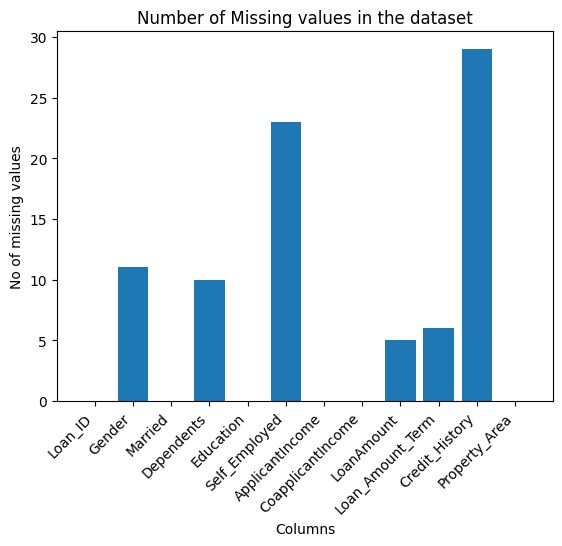

For the feature: ApplicantIncome , These are the outlirers: 
      Loan_ID  Gender Married Dependents     Education Self_Employed  \
8    LP001059    Male     Yes          2      Graduate           NaN   
13   LP001094    Male     Yes          2      Graduate           NaN   
18   LP001108    Male     Yes          0      Graduate            No   
81   LP001428    Male     Yes         3+      Graduate            No   
83   LP001446    Male     Yes          0      Graduate            No   
91   LP001483    Male     Yes         3+      Graduate            No   
98   LP001517    Male     Yes         3+      Graduate            No   
124  LP001655  Female      No          0      Graduate            No   
143  LP001791    Male     Yes          0      Graduate           Yes   
144  LP001794    Male     Yes          2      Graduate           Yes   
145  LP001797  Female      No          0      Graduate            No   
147  LP001817    Male      No          0  Not Graduate           Yes   
179

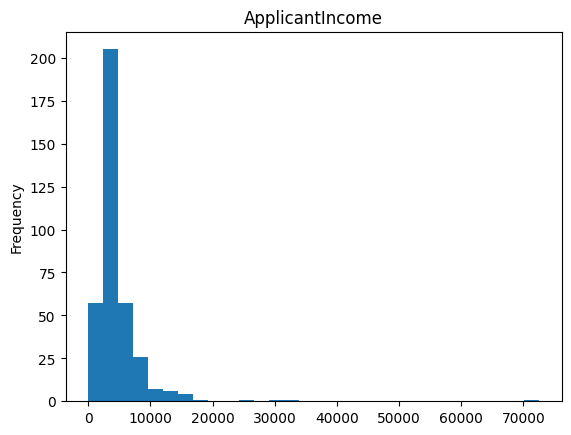

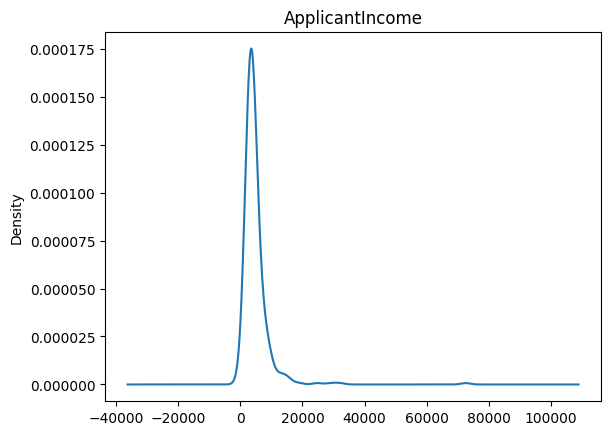

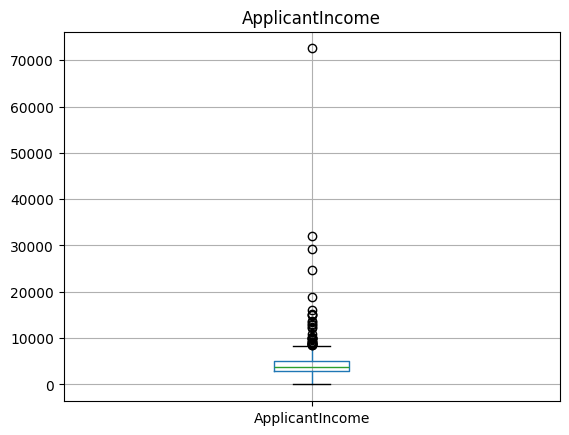

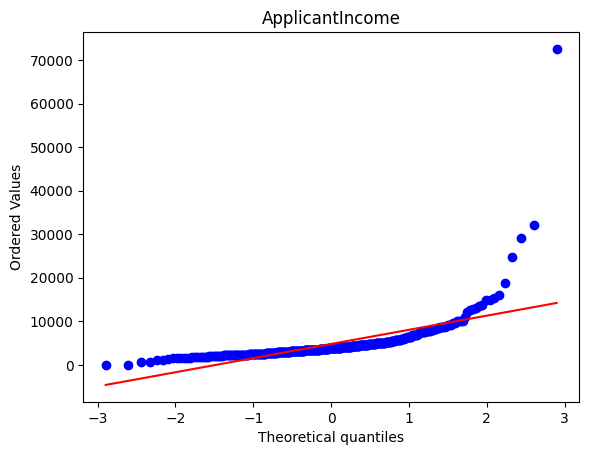

What task do you want to perform for the column ApplicantIncome: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs after the desired action performed: ApplicantIncome


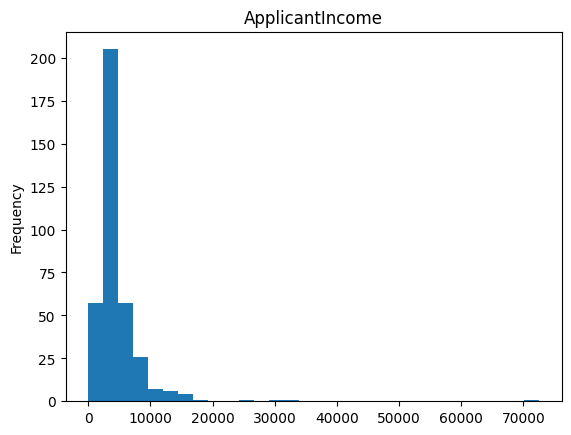

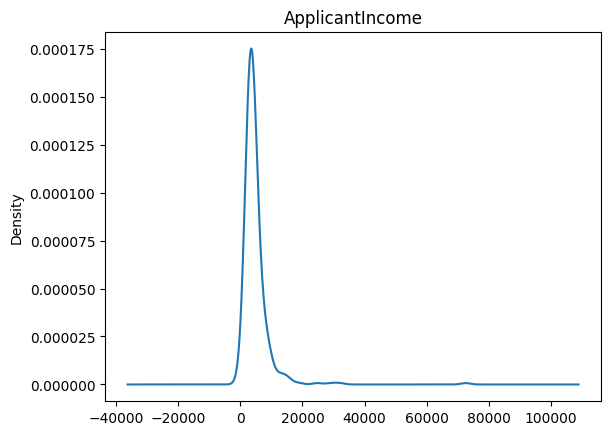

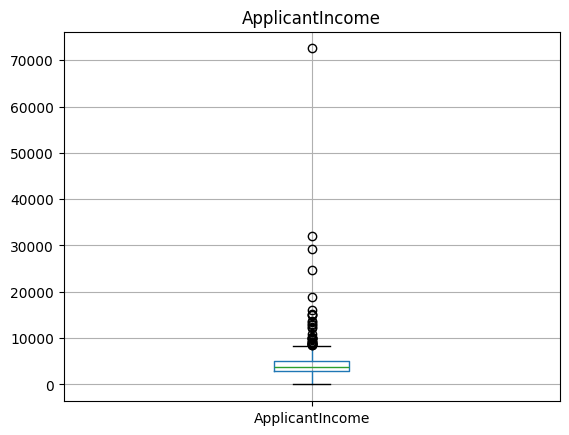

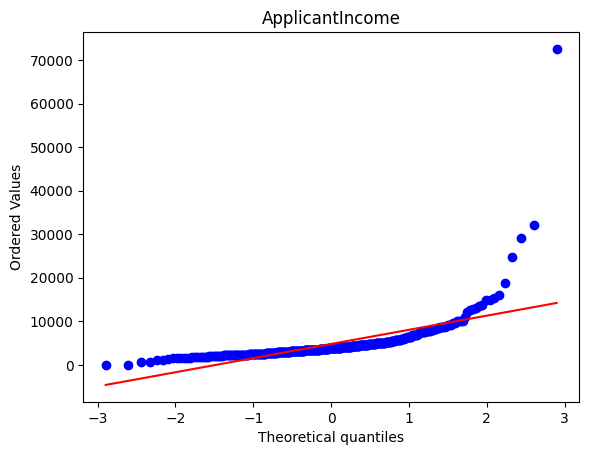

These are the graphs relating to feature: CoapplicantIncome


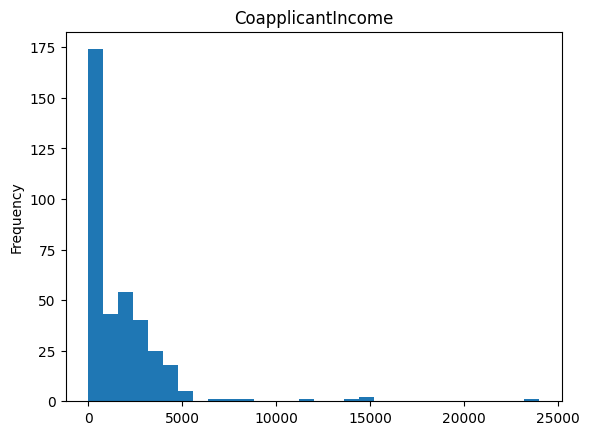

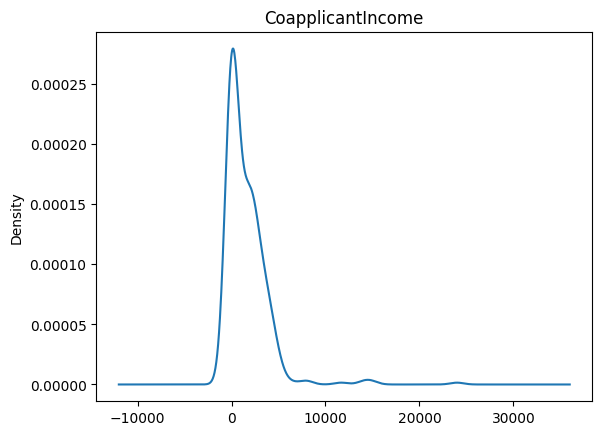

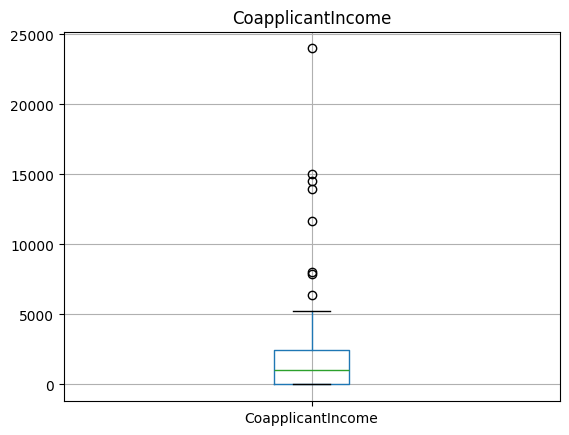

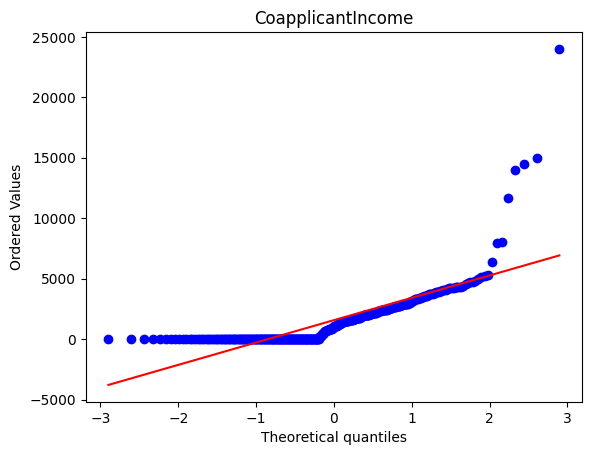

What task do you want to perform for the column CoapplicantIncome: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs after the desired action performed: CoapplicantIncome


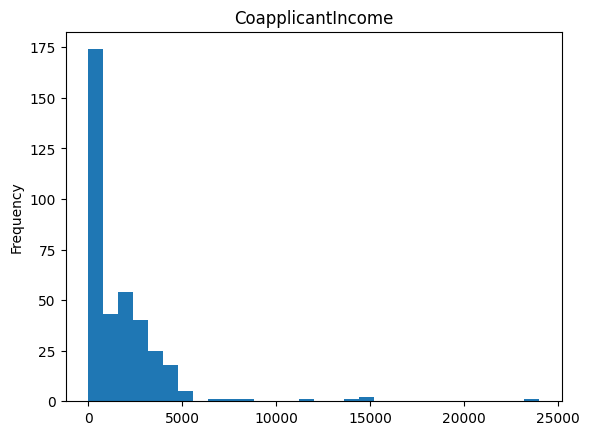

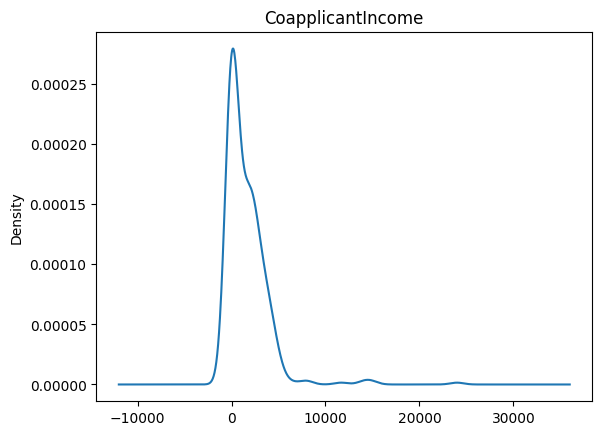

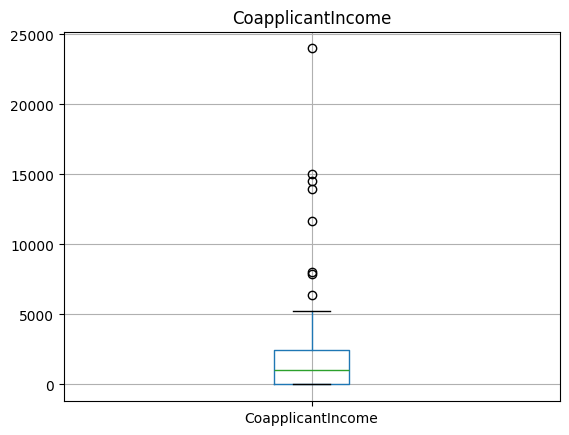

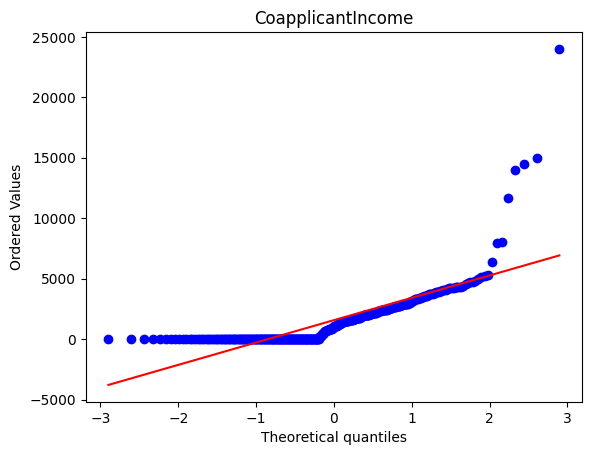

These are the graphs relating to feature: LoanAmount


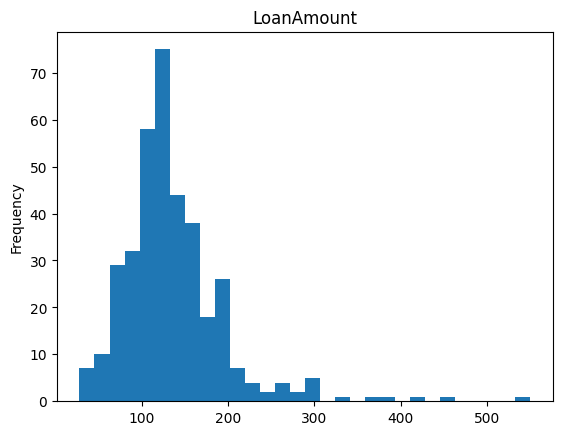

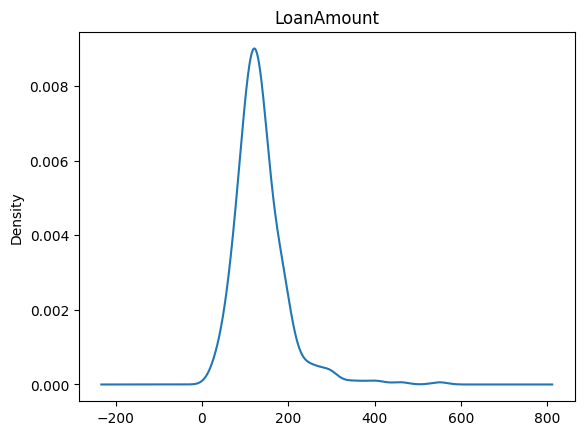

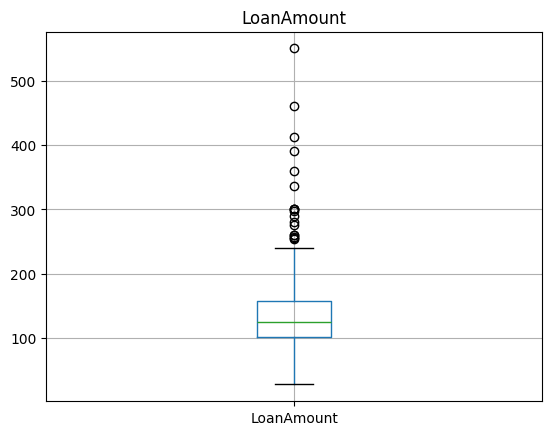

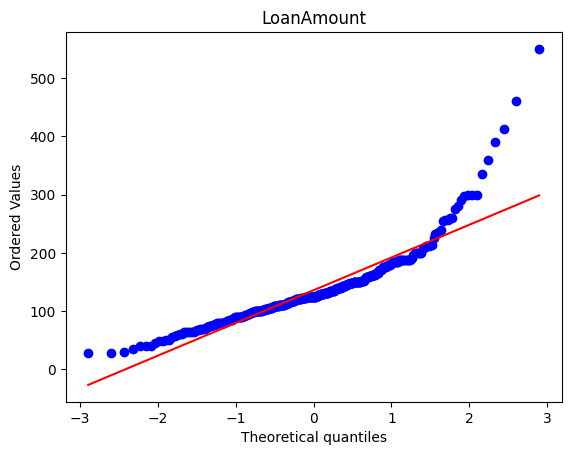

What task do you want to perform for the column LoanAmount: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs after the desired action performed: LoanAmount


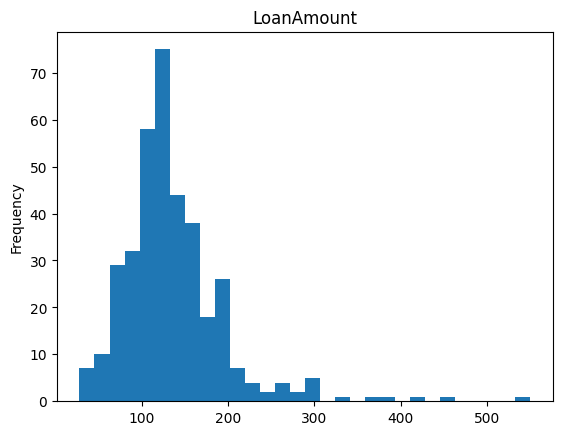

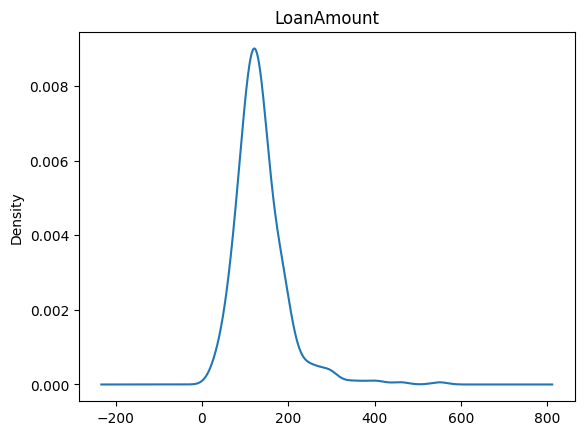

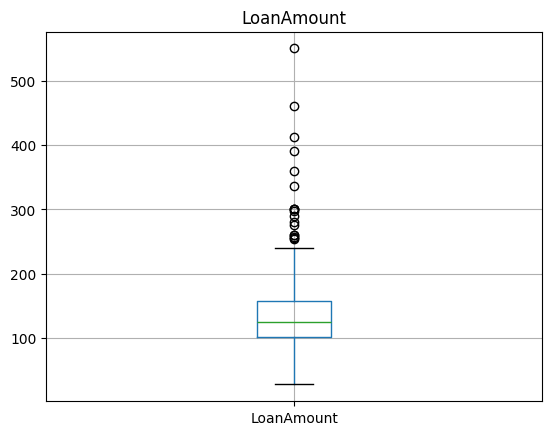

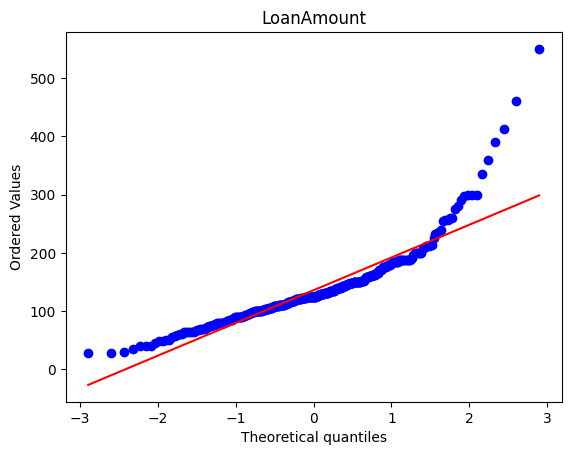

These are the graphs relating to feature: Loan_Amount_Term


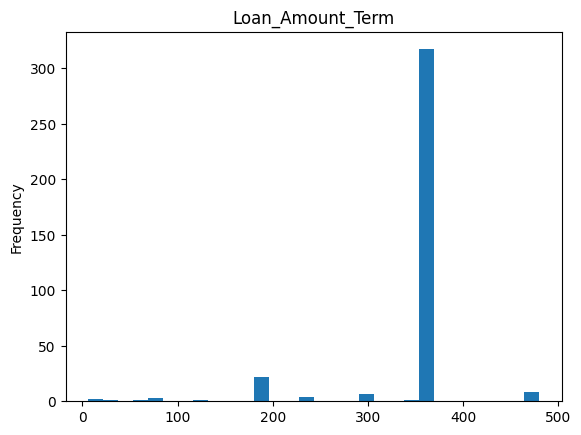

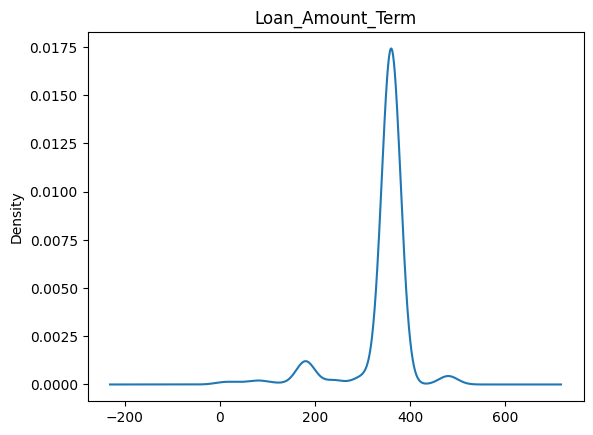

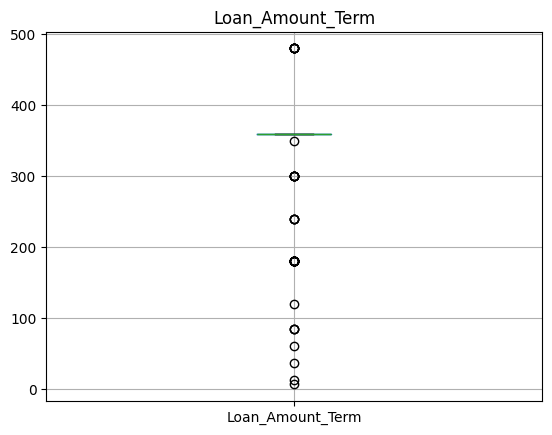

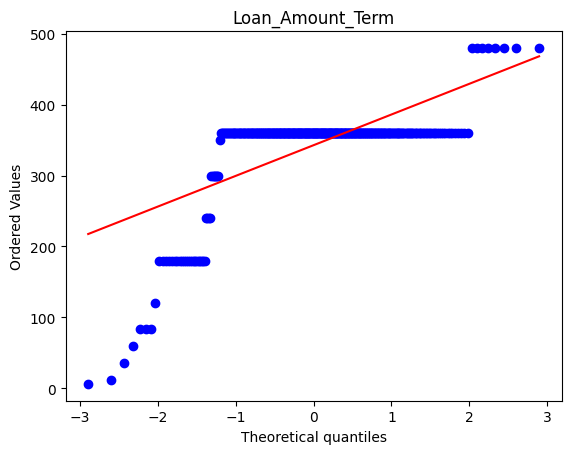

What task do you want to perform for the column Loan_Amount_Term: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs after the desired action performed: Loan_Amount_Term


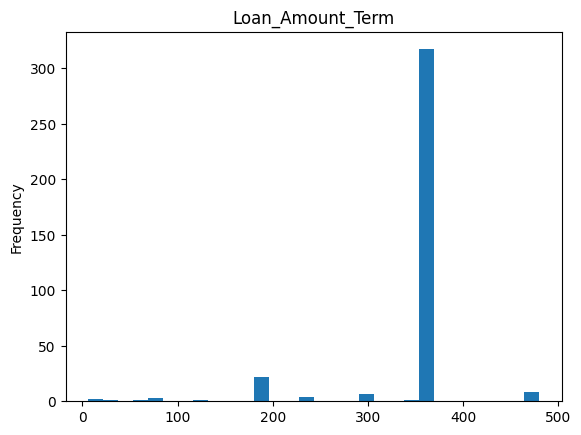

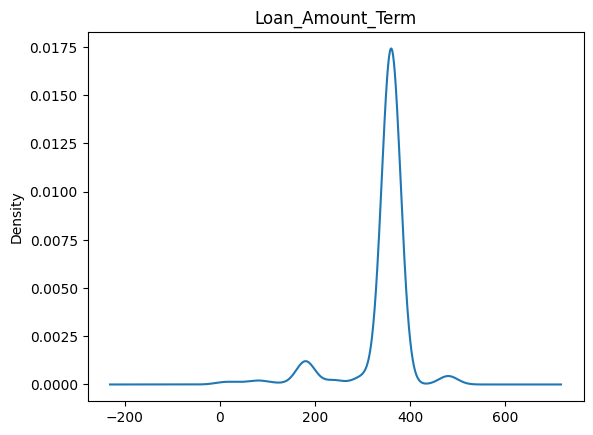

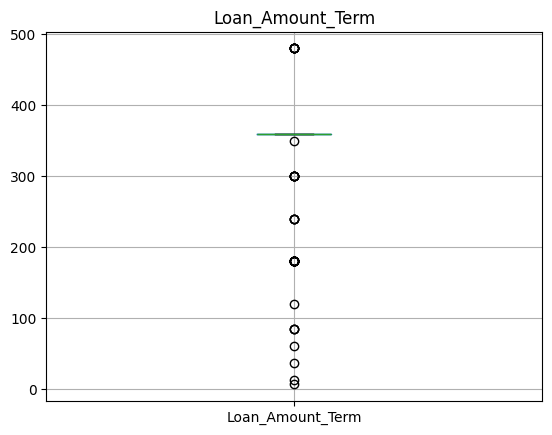

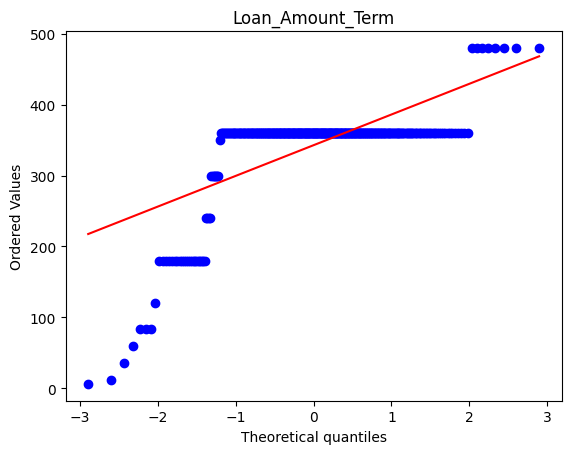

These are the graphs relating to feature: Credit_History


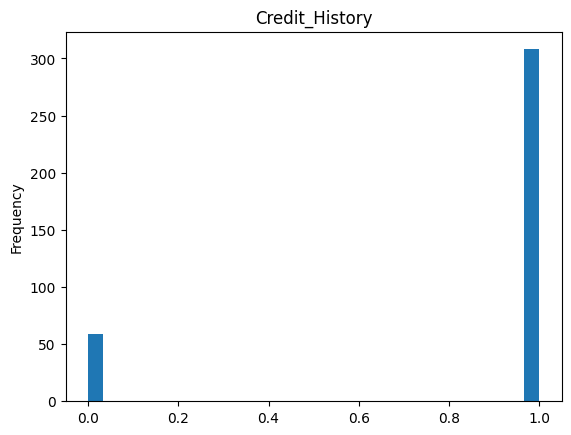

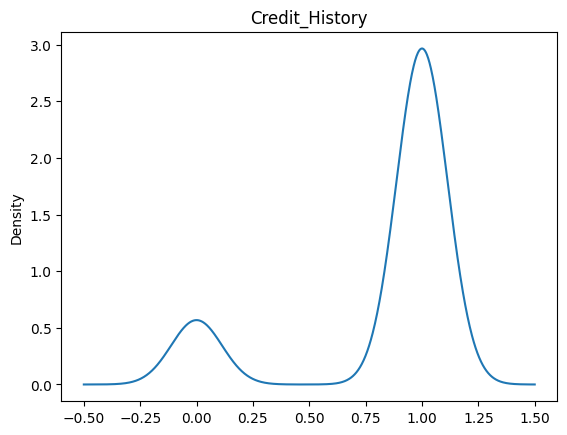

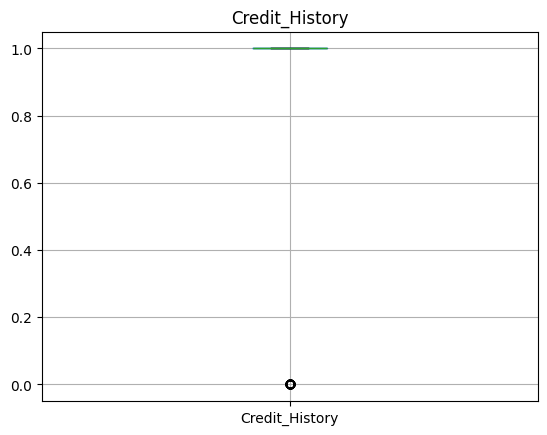

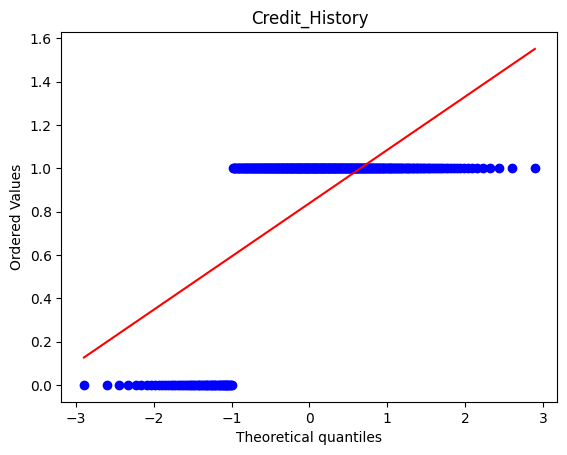

What task do you want to perform for the column Credit_History: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs after the desired action performed: Credit_History


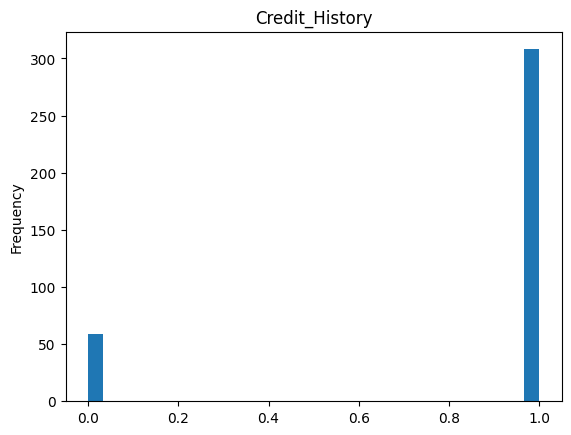

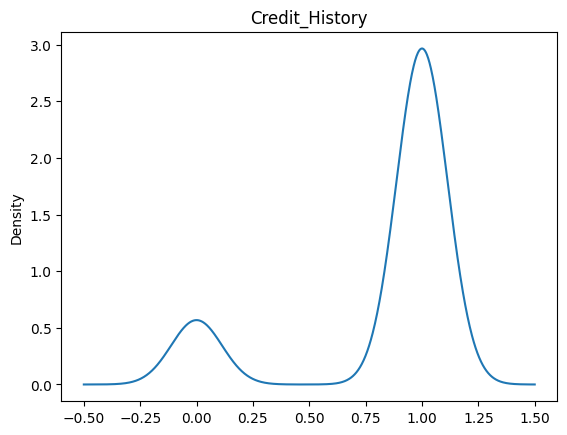

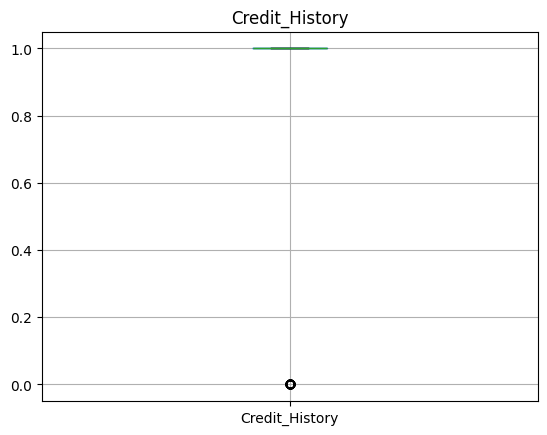

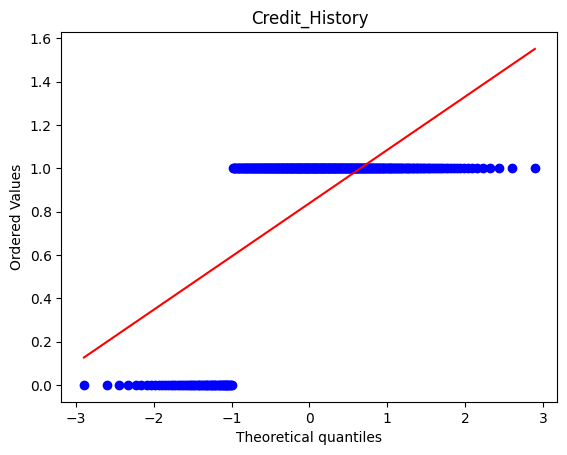

Graphs of all the categorical features:


C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


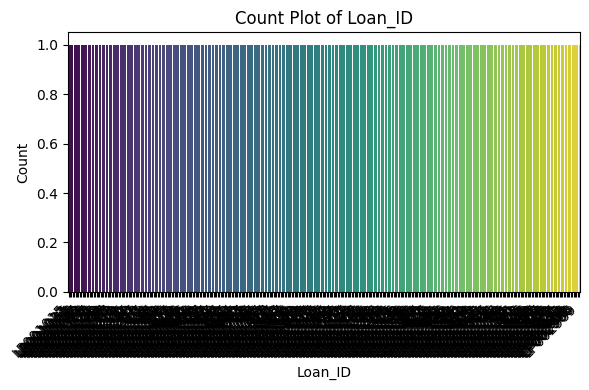

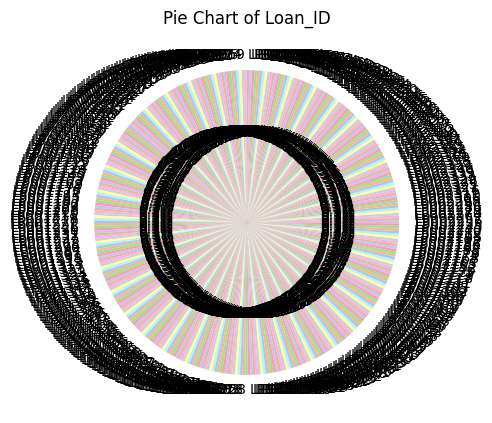

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


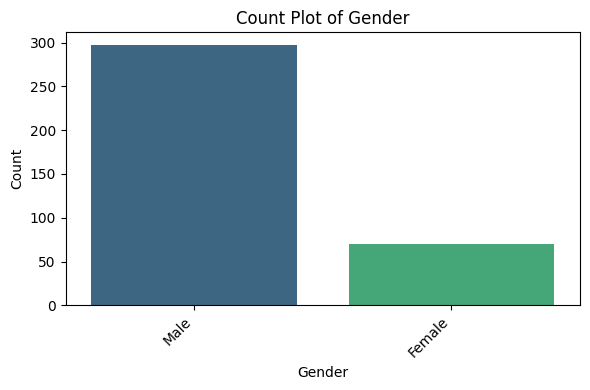

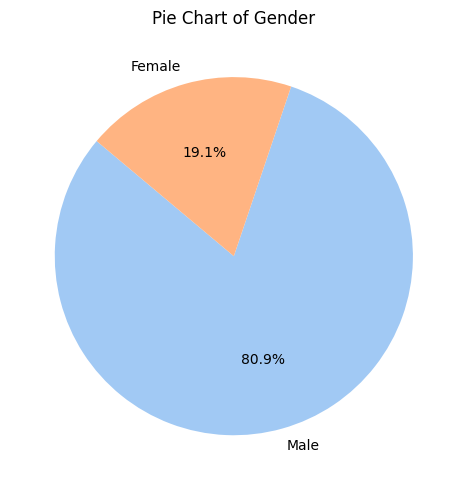

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


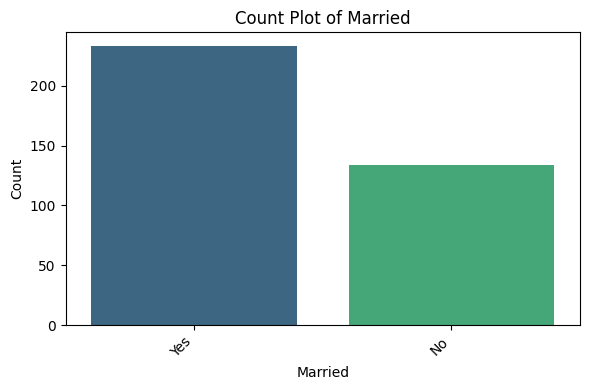

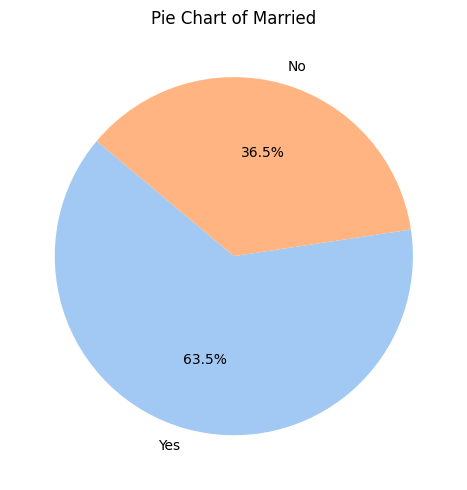

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


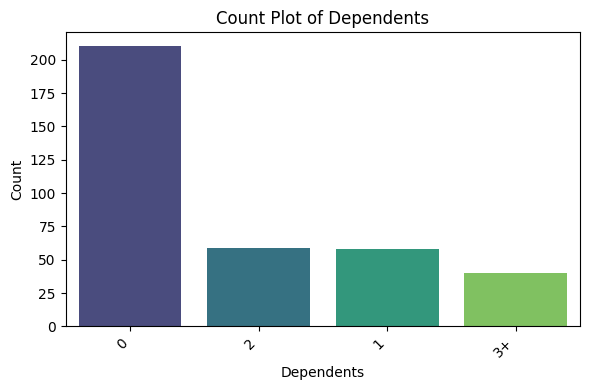

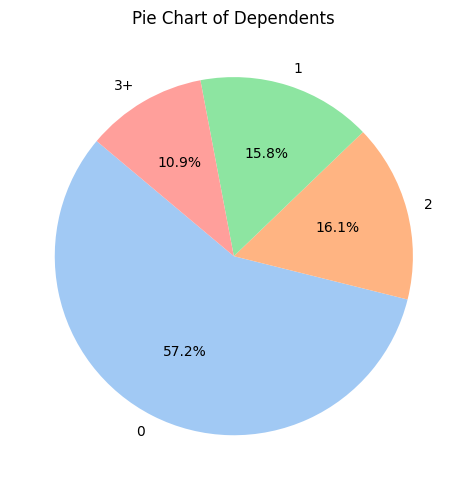

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


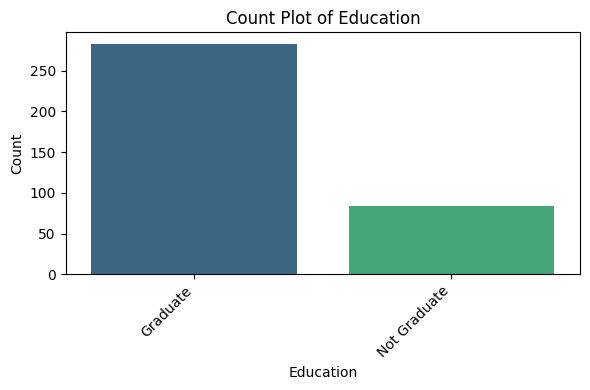

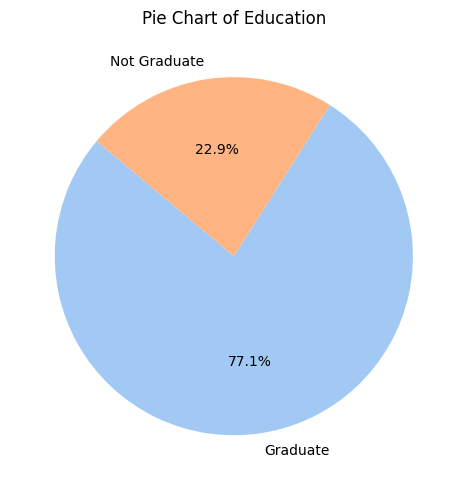

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


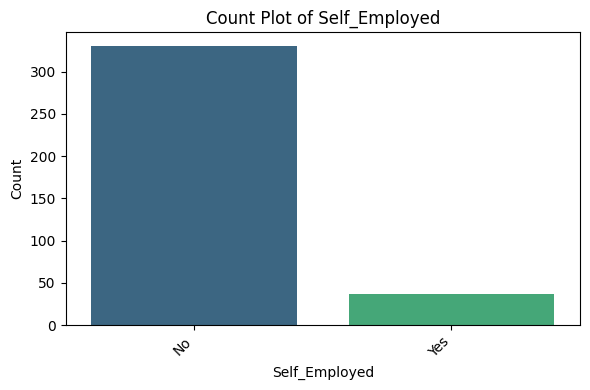

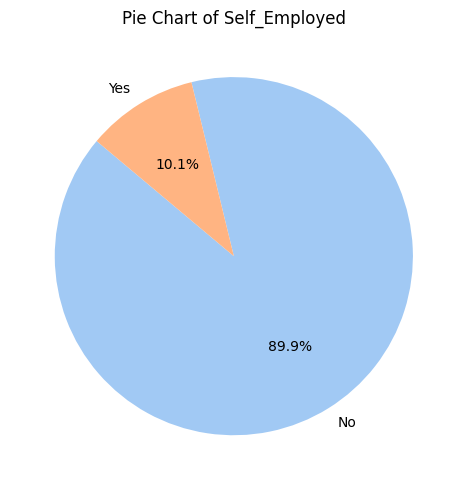

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_60664\3892250750.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


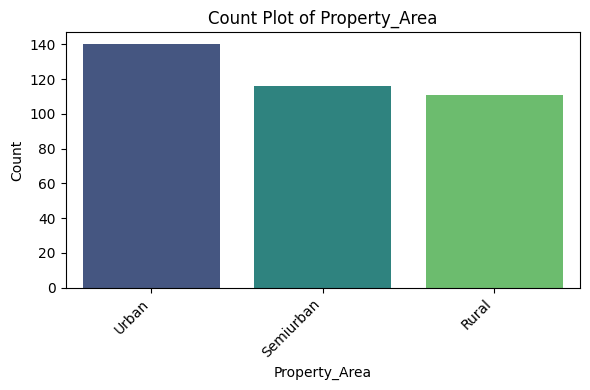

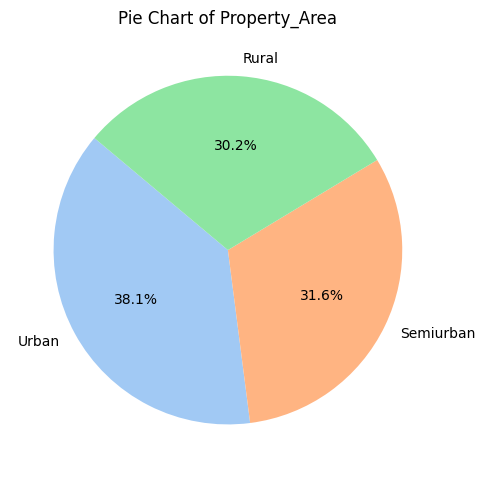

Whats the nature of this column Loan_ID?
1. Ordered
2. Unorderd
Whats the nature of this column Gender?
1. Ordered
2. Unorderd
Whats the nature of this column Married?
1. Ordered
2. Unorderd
Whats the nature of this column Dependents?
1. Ordered
2. Unorderd
Whats the nature of this column Education?
1. Ordered
2. Unorderd
Whats the nature of this column Self_Employed?
1. Ordered
2. Unorderd
Whats the nature of this column Property_Area?
1. Ordered
2. Unorderd
             Feature  Regression Score
0    ApplicantIncome        114.546027
1  CoapplicantIncome          8.405477
2   Loan_Amount_Term          3.106627
3     Credit_History          0.061052


In [26]:
data = eda(data)
feature_selection(data, "LoanAmount")